# Part A

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("m1-09-assessment.csv",parse_dates=["date"])

In [3]:
df.set_index("date",inplace=True)

In [28]:
df.tail()

,city,avg_temp_c,humidity_pct,pm25,high_pollution,month,rolling_pm25
date,,,,,,,
2023-06-25,Madrid,NaN,72.04,5.00,False,2023-06,10.425714
2023-06-26,Madrid,28.44,74.19,5.00,False,2023-06,10.150000
2023-06-27,Madrid,26.41,64.41,5.24,False,2023-06,9.442857
2023-06-28,Madrid,27.53,86.47,14.86,False,2023-06,9.957143
2023-06-29,Madrid,24.22,74.33,10.57,False,2023-06,11.134286


In [29]:
df.head()

,city,avg_temp_c,humidity_pct,pm25,high_pollution,month,rolling_pm25
date,,,,,,,
2023-01-01,London,-0.79,62.93,39.39,True,2023-01,NaN
2023-01-02,London,1.31,61.49,32.41,False,2023-01,NaN
2023-01-03,London,1.46,76.51,30.61,False,2023-01,NaN
2023-01-04,London,-0.57,58.05,30.71,False,2023-01,NaN
2023-01-05,London,-1.13,36.30,20.70,False,2023-01,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 900 entries, 2023-01-01 to 2023-06-29
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   city          900 non-null    object 
 1   avg_temp_c    863 non-null    float64
 2   humidity_pct  900 non-null    float64
 3   pm25          850 non-null    float64
dtypes: float64(3), object(1)
memory usage: 35.2+ KB


In [6]:
df.describe()

,avg_temp_c,humidity_pct,pm25
count,863.000000,900.000000,850.000000
mean,9.259849,64.931011,23.961247
std,9.134278,14.432234,11.856849
min,-15.030000,35.000000,5.000000
25%,1.410000,54.672500,14.090000
50%,9.790000,64.870000,23.710000
75%,16.775000,75.190000,33.427500
max,30.390000,95.000000,60.600000


In [7]:
df.isna().sum()

city             0
avg_temp_c      37
humidity_pct     0
pm25            50
dtype: int64

In [8]:
df_=df.copy()

In [9]:
df["pm25"]=pd.to_numeric(df["pm25"],errors="coerce")

In [10]:
df["pm25"].isna().sum()

np.int64(50)

In [11]:
df["pm25"]=df["pm25"].interpolate(method="time")
df["pm25"]

date
2023-01-01    39.39
2023-01-02    32.41
2023-01-03    30.61
2023-01-04    30.71
2023-01-05    20.70
              ...  
2023-06-25     5.00
2023-06-26     5.00
2023-06-27     5.24
2023-06-28    14.86
2023-06-29    10.57
Name: pm25, Length: 900, dtype: float64

###### 
I handled missing pm25 values using time-based interpolation. This method fills missing values by looking at the values before and after in time and estimating a reasonable value between them. Since pm25 changes gradually over time, this approach keeps the data realistic and avoids sharp jumps. It also helps maintain accurate trends for further analysis.

# Part B

In [12]:
highest_missing=pd.DataFrame({
    "total_values": df_.groupby("city").size(),
    "missing_values": df_["pm25"].isna().groupby(df_["city"]).sum()
})
highest_missing["invalid_perc"]=highest_missing["missing_values"]/highest_missing["total_values"]*100
highest_missing.sort_values("invalid_perc",ascending=False).head(1)

,total_values,missing_values,invalid_perc
city,,,
Berlin,180,14,7.777778


In [13]:
rolling_avg=df.groupby("city")["pm25"].rolling(window=7).mean()

In [14]:
rolling_avg

city    date      
Berlin  2023-01-01          NaN
        2023-01-02          NaN
        2023-01-03          NaN
        2023-01-04          NaN
        2023-01-05          NaN
                        ...    
Warsaw  2023-06-25    10.425714
        2023-06-26    10.150000
        2023-06-27     9.442857
        2023-06-28     9.957143
        2023-06-29    11.134286
Name: pm25, Length: 900, dtype: float64

###### 
I calculated a 7 day rolling average of pm25 for each city.This method takes the average of the last 7 days, including the current day.
I used this because daily pm25 values change a lot from day to day. These changes can make the data hard to understand.
The 7 day rolling average makes the data smoother and helps me see the general trend more clearly.

In [15]:
threshold=df["pm25"].quantile(0.90)

In [16]:
df["high_pollution"]=df["pm25"]>=threshold

In [17]:
events_per_city=(df[df["high_pollution"]==True].groupby("city").size().reset_index(name="high_pollution_events"))

In [18]:
events_per_city

,city,high_pollution_events
0,Berlin,14
1,London,17
2,Madrid,20
3,Paris,17
4,Warsaw,22


In [19]:
volatility = (df[df["city"].isin(["London", "Madrid"])].groupby("city")["pm25"].std().reset_index(name="volatility_std"))
volatility

,city,volatility_std
0,London,12.305268
1,Madrid,11.559398


###### I used standard deviation to measure the volatility of pm25 levels.
Standard deviation shows how much the values differ from the average. If the std is high, pm25 levels change a lot over time. If the std is low, pollution levels are more stable.
I chose this metric because it is simple to calculate, easy to interpret, and directly shows how spread out the data is. It clearly reflects how unstable or stable air quality is in each city.

In [20]:
df["month"] = df.index.to_period("M")
pivot_table = df.pivot_table(
    values="pm25",
    index="month",
    columns="city",
    aggfunc="mean"
)
pivot_table

city,Berlin,London,Madrid,Paris,Warsaw
month,,,,,
2023-01,33.193226,33.275806,33.006452,35.021935,37.239032
2023-02,33.117500,33.274286,34.651786,34.326786,34.818571
2023-03,29.531613,29.737742,30.315484,26.736774,27.736129
2023-04,21.855667,24.864333,22.269000,23.049333,20.749333
2023-05,15.200645,13.987742,15.118387,14.055161,14.262903
2023-06,9.872759,9.099310,10.201724,9.280345,9.288966


# Part C

In [21]:
avg_pm25_by_city=df.groupby("city")["pm25"].mean().reset_index(name="pm25_avg")
avg_pm25_by_city

,city,pm25_avg
0,Berlin,23.805333
1,London,24.047389
2,Madrid,24.254556
3,Paris,23.733278
4,Warsaw,24.017556


In [22]:
monthly_avg_pm25 = (df.groupby(["city", pd.Grouper(freq="M")])["pm25"].mean().reset_index(name="monthly_avg"))
monthly_avg_pm25

C:\Users\User\AppData\Local\Temp\ipykernel_11916\287720549.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg_pm25 = (df.groupby(["city", pd.Grouper(freq="M")])["pm25"].mean().reset_index(name="monthly_avg"))


,city,date,monthly_avg
0,Berlin,2023-01-31,33.193226
1,Berlin,2023-02-28,33.117500
2,Berlin,2023-03-31,29.531613
3,Berlin,2023-04-30,21.855667
4,Berlin,2023-05-31,15.200645
5,Berlin,2023-06-30,9.872759
6,London,2023-01-31,33.275806
7,London,2023-02-28,33.274286
8,London,2023-03-31,29.737742
9,London,2023-04-30,24.864333


In [23]:
hottest_day_per_city = df.loc[df["avg_temp_c"].idxmax()]
hottest_day_per_city

,city,avg_temp_c,humidity_pct,pm25,high_pollution,month
date,,,,,,
2023-06-10,London,NaN,50.67,5.00,False,2023-06
2023-06-10,Berlin,18.86,56.39,8.47,False,2023-06
2023-06-10,Warsaw,17.74,53.79,8.47,False,2023-06
2023-06-10,Paris,20.58,51.47,5.00,False,2023-06
2023-06-10,Madrid,30.39,61.73,5.00,False,2023-06


# Part D

<Figure size 640x480 with 0 Axes>

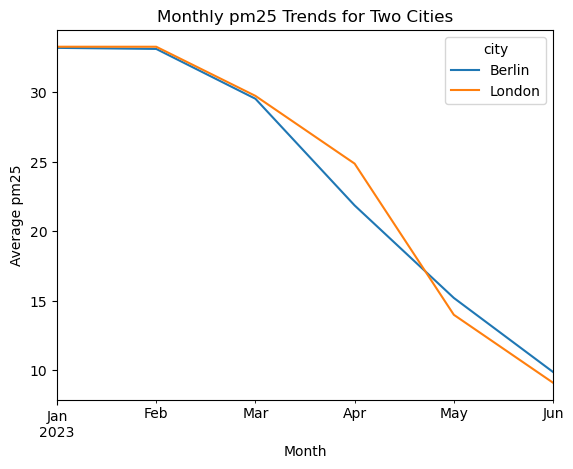

In [24]:
cities = monthly_avg_pm25["city"].unique()[:2]
plot_data = monthly_avg_pm25[monthly_avg_pm25["city"].isin(cities)]

pivot_df = plot_data.pivot(
    index="date",
    columns="city",
    values="monthly_avg"
)
plt.figure()
pivot_df.plot()
plt.xlabel("Month")
plt.ylabel("Average pm25")
plt.title("Monthly pm25 Trends for Two Cities")
plt.show()

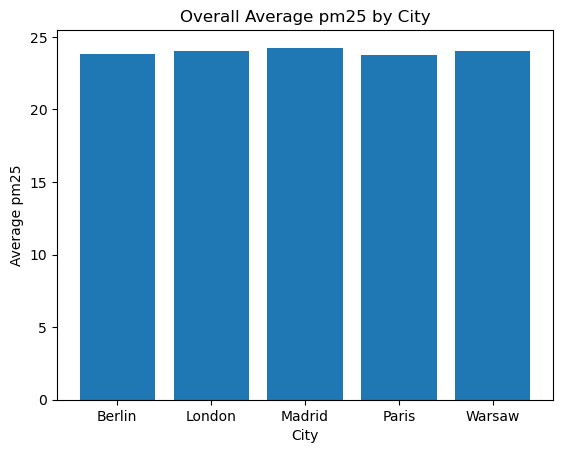

In [25]:
plt.bar(avg_pm25_by_city["city"],avg_pm25_by_city["pm25_avg"])
plt.xlabel("City")
plt.ylabel("Average pm25")
plt.title("Overall Average pm25 by City")
plt.show()

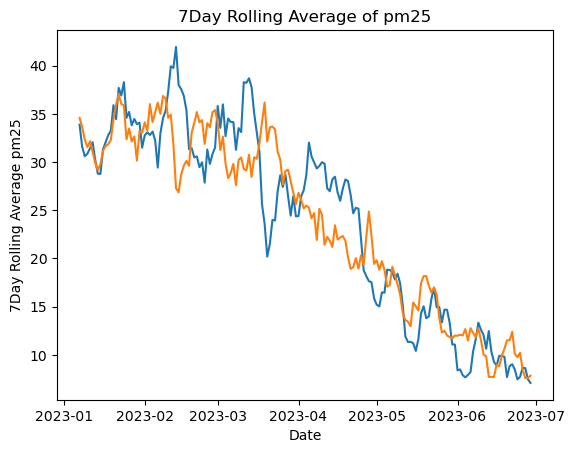

In [26]:
df["rolling_pm25"] = df.groupby("city")["pm25"].rolling(7).mean().reset_index(level=0, drop=True)
df_two = df[df["city"].isin(cities)]
plt.figure()
for city in cities:
    city_data = df_two[df_two["city"] == city]
    plt.plot(city_data.index, city_data["rolling_pm25"], label=city)
plt.xlabel("Date")
plt.ylabel("7Day Rolling Average pm25")
plt.title("7Day Rolling Average of pm25")
plt.show()

# Part E

###### 1.Which city shows the most persistent high pm25 levels, and what evidence supports that?
The city with the most persistent high pm25 levels is Warsaw. It had 22 days where pm25 was above the 90th percentile threshold, which is the highest among all cities. This means that high air pollution happened more often in Warsaw than in other cities. Therefore, Warsaw shows more consistent and long-lasting pm25 pollution.

###### 2.How does missing or invalid data affect your confidence in the results?
Missing or invalid pm25 data affected my confidence because some days were missing or incorrect, so the averages and trends might not reflect the true air quality perfectly. Even though I used time-based interpolation to fill the gaps, there is still some uncertainty, so I have to be careful when interpreting the results.

###### 3.Does temperature appear related to pm25 in your analysis? Explain briefly.
Temperature doesn’t seem to have a strong effect on pm25. Some high pm25 days happen when it’s cold, some when it’s warm, so I couldn’t see a clear pattern between temperature and air pollution.

###### 4.What is one limitation of using daily averages for air-quality policy decisions?
Using daily averages in this dataset can hide short periods of very high pm25. Even if the daily average looks moderate, there can be hours when pollution is much higher, which daily averages do not capture. This means that relying only on daily averages could underestimate the risk of exposure to poor air quality.

###### 5.If you had one more dataset to improve this analysis, what would it be and why?
If I had one more dataset, it would be complete temperature data (avg_temp_c) without missing values. In my current dataset, some temperature values are missing, which makes it hard to be completely sure about the hottest day or study temperature patterns. A full dataset would give a more accurate picture of temperature trends across cities.